# Concept Bottleneck Models — MNIST Demo

**Paper**: Koh et al., *Concept Bottleneck Models* (ICML 2020)

### The idea

A standard neural network is a black box: `Image → [hidden magic] → Label`.

A **Concept Bottleneck Model (CBM)** forces the network to first predict human-understandable
**concepts**, then predict the final label from those concepts alone:

```
Image  →  [CNN backbone]  →  Concept Predictions  →  [Linear layer]  →  Label
                              (interpretable!)         (interpretable!)
```

### Why this matters

1. **Interpretability**: You can inspect *why* the model made a prediction — which concepts activated?
2. **Intervention**: A human expert can *correct* wrong concept predictions at test time to fix errors
3. **Debuggability**: When the model fails, you can see *where* it went wrong (bad concept? bad label mapping?)

### The tradeoff

The bottleneck constrains information flow. If your concepts don't capture enough information
to distinguish all classes, accuracy **will** suffer. This is fundamental, not a bug — it's
the price of interpretability.

### What this notebook covers

1. Why concept design is critical (and what goes wrong with bad concepts)
2. Three CBM training strategies: **joint**, **sequential**, **hybrid**
3. Concept intervention demo
4. The full accuracy–interpretability spectrum

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
%config InlineBackend.figure_format = 'retina'

Device: cpu


## 1. Concept Design — The Make-or-Break Step

The most important part of a CBM is choosing the right concepts. Here's the key rule:

> **Every class must have a unique combination of concepts.** If two classes share the same
> concept vector, no linear head can distinguish them — even with perfect concept predictions.

We define **10 binary visual concepts** for MNIST digits. Each digit gets a unique "concept fingerprint":

| Concept | Description | Which digits? |
|---------|-------------|---------------|
| `top_loop` | Enclosed region in upper half | 0, 8, 9 |
| `bottom_loop` | Enclosed region in lower half | 0, 6, 8 |
| `vertical_stroke` | Prominent vertical line | 1, 4, 7 |
| `top_horizontal` | Horizontal stroke near top | 5, 7 |
| `mid_horizontal` | Horizontal stroke in middle | 4, 5, 6 |
| `bottom_horizontal` | Horizontal stroke near bottom | 2, 5, 7 |
| `open_right` | Open/curves toward right side | 2, 3 |
| `curves_left` | Curves toward left side | 5, 6 |
| `diagonal_stroke` | Has a diagonal component | 2, 4, 7 |
| `narrow_waist` | Narrower in the middle | 3, 8, 9 |

All 10 digits have unique concept signatures.


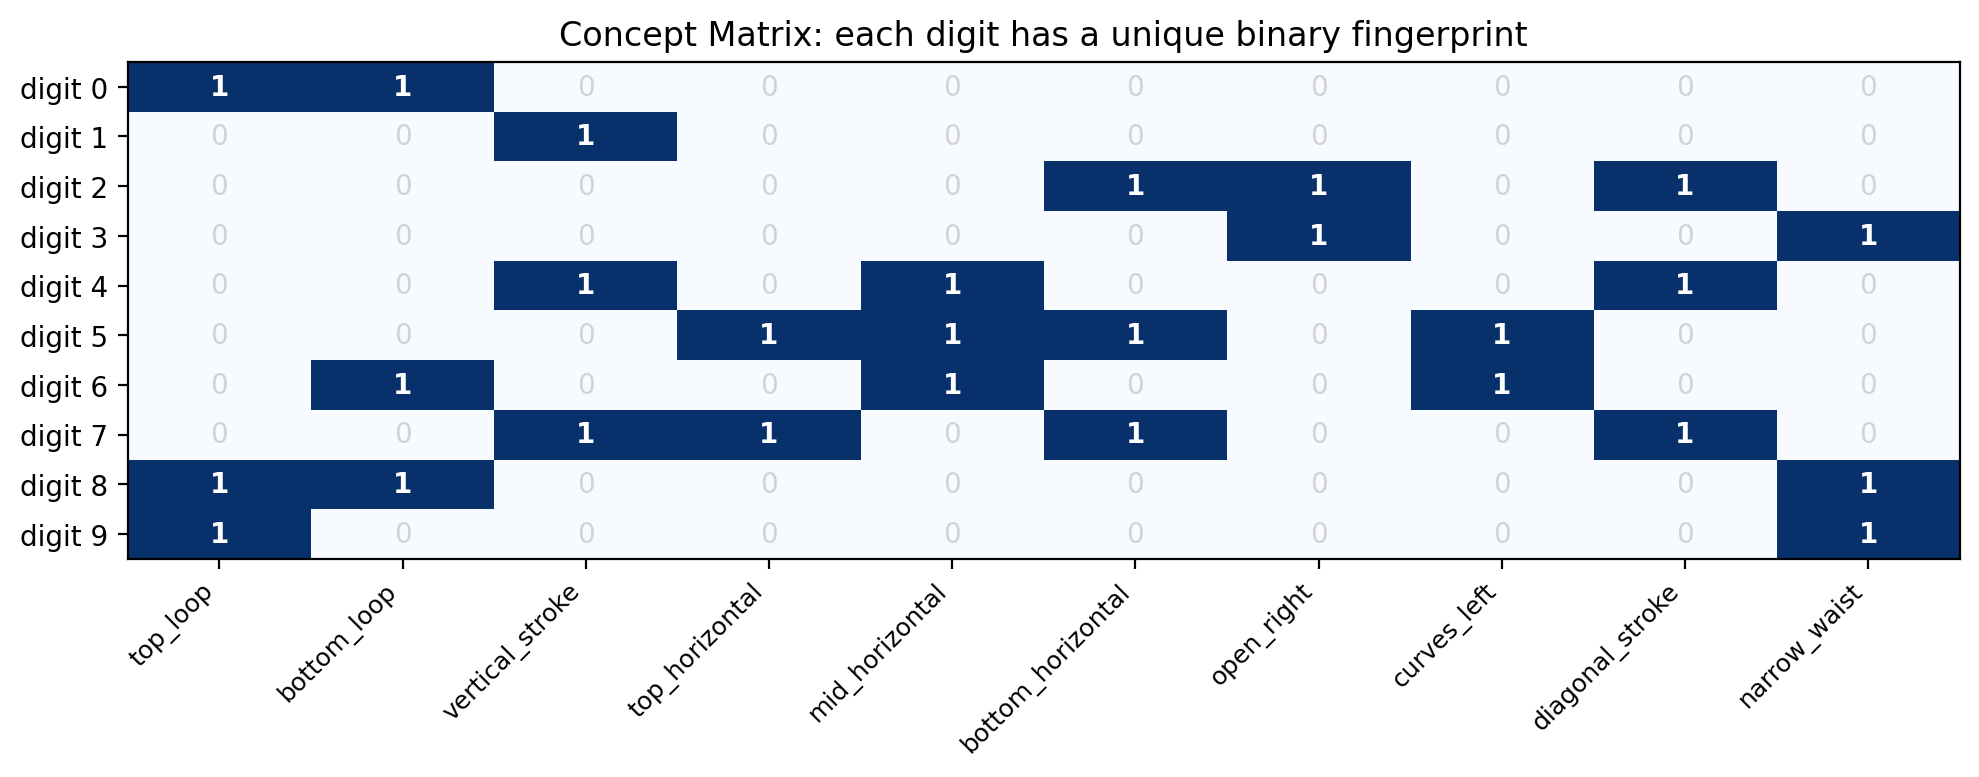

In [14]:
CONCEPT_NAMES = [
    "top_loop", "bottom_loop", "vertical_stroke", "top_horizontal",
    "mid_horizontal", "bottom_horizontal", "open_right", "curves_left",
    "diagonal_stroke", "narrow_waist"
]
NUM_CONCEPTS = len(CONCEPT_NAMES)
NUM_CLASSES = 10

# Each row = digit (0-9), each column = concept
# CRITICAL: every row must be unique!
concept_matrix = torch.tensor([
    # top_l  bot_l  vert  top_h  mid_h  bot_h  open_r  crv_l  diag  waist
    [  1,     1,     0,    0,     0,     0,     0,      0,     0,    0   ],  # 0: two loops, no strokes
    [  0,     0,     1,    0,     0,     0,     0,      0,     0,    0   ],  # 1: just a vertical stroke
    [  0,     0,     0,    0,     0,     1,     1,      0,     1,    0   ],  # 2: curves right, diagonal, flat bottom
    [  0,     0,     0,    0,     0,     0,     1,      0,     0,    1   ],  # 3: open right, narrow waist
    [  0,     0,     1,    0,     1,     0,     0,      0,     1,    0   ],  # 4: vertical, mid bar, diagonal
    [  0,     0,     0,    1,     1,     1,     0,      1,     0,    0   ],  # 5: horizontal bars, curves left
    [  0,     1,     0,    0,     1,     0,     0,      1,     0,    0   ],  # 6: bottom loop, mid bar, curves left
    [  0,     0,     1,    1,     0,     1,     0,      0,     1,    0   ],  # 7: vertical, top & bottom horiz, diagonal
    [  1,     1,     0,    0,     0,     0,     0,      0,     0,    1   ],  # 8: two loops + narrow waist
    [  1,     0,     0,    0,     0,     0,     0,      0,     0,    1   ],  # 9: top loop + narrow waist
], dtype=torch.float32)

# Verify all rows are unique
for i in range(10):
    for j in range(i+1, 10):
        assert not torch.equal(concept_matrix[i], concept_matrix[j]), \
            f"Collision! Digits {i} and {j} have identical concept vectors"
print("All 10 digits have unique concept signatures.")

def labels_to_concepts(labels):
    return concept_matrix[labels]

# Show the matrix
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(concept_matrix.numpy(), cmap='Blues', aspect='auto')
ax.set_xticks(range(NUM_CONCEPTS))
ax.set_xticklabels(CONCEPT_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(10))
ax.set_yticklabels([f'digit {i}' for i in range(10)])
ax.set_title('Concept Matrix: each digit has a unique binary fingerprint')
for i in range(10):
    for j in range(NUM_CONCEPTS):
        ax.text(j, i, int(concept_matrix[i, j].item()), ha='center', va='center',
                fontsize=10, fontweight='bold' if concept_matrix[i,j] else 'normal',
                color='white' if concept_matrix[i,j] else 'lightgray')
plt.tight_layout()
plt.show()

## 2. Load MNIST

In [15]:
train_data = datasets.MNIST(root='./data', train=True, download=True,
                            transform=transforms.ToTensor())
test_data = datasets.MNIST(root='./data', train=False, download=True,
                           transform=transforms.ToTensor())

# Use a 20k/4k split — enough to train well, fast enough to iterate
TRAIN_SIZE = 20000
TEST_SIZE = 4000

train_imgs = train_data.data[:TRAIN_SIZE].float().unsqueeze(1) / 255.0
train_labels = train_data.targets[:TRAIN_SIZE]
train_concepts = labels_to_concepts(train_labels)

test_imgs = test_data.data[:TEST_SIZE].float().unsqueeze(1) / 255.0
test_labels = test_data.targets[:TEST_SIZE]
test_concepts = labels_to_concepts(test_labels)

train_ds = TensorDataset(train_imgs, train_concepts, train_labels)
test_ds = TensorDataset(test_imgs, test_concepts, test_labels)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=256)

print(f"Train: {len(train_ds):,}  |  Test: {len(test_ds):,}")
print(f"Image shape: {train_imgs[0].shape}  |  Concepts per image: {NUM_CONCEPTS}")

Train: 20,000  |  Test: 4,000
Image shape: torch.Size([1, 28, 28])  |  Concepts per image: 10


## 3. Model Definitions

We build four models to compare the full accuracy–interpretability spectrum:

| Model | Architecture | Interpretable? | Intervenable? |
|-------|-------------|----------------|---------------|
| **Standard** | image → label | No | No |
| **CBM (Joint)** | image → concepts → label (end-to-end) | Yes | Yes |
| **CBM (Sequential)** | train concepts first, freeze, then train label head | Yes | Yes |
| **Hybrid CBM** | image → concepts + residual → label | Partial | Partial |

In [16]:
def make_backbone():
    """Shared CNN backbone for all models."""
    return nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.3),
    )

BACKBONE_OUT = 128


class StandardModel(nn.Module):
    """Black-box: image → label. No concepts, no interpretability."""
    def __init__(self):
        super().__init__()
        self.backbone = make_backbone()
        self.head = nn.Linear(BACKBONE_OUT, NUM_CLASSES)
    
    def forward(self, x):
        return self.head(self.backbone(x))


class ConceptBottleneckModel(nn.Module):
    """
    CBM: image → concepts → label.
    
    The key constraint: ALL information flowing to the label head must pass through
    the concept bottleneck. This is what makes it interpretable AND intervenable.
    """
    def __init__(self):
        super().__init__()
        self.backbone = make_backbone()
        self.concept_head = nn.Linear(BACKBONE_OUT, NUM_CONCEPTS)
        self.label_head = nn.Sequential(
            nn.Linear(NUM_CONCEPTS, NUM_CLASSES),
        )
    
    def forward(self, x, concept_override=None):
        h = self.backbone(x)
        concept_logits = self.concept_head(h)
        concept_probs = torch.sigmoid(concept_logits)
        
        # INTERVENTION: replace predicted concepts with human-provided ones
        if concept_override is not None:
            concept_probs = concept_override
        
        label_logits = self.label_head(concept_probs)
        return concept_logits, concept_probs, label_logits


class HybridCBM(nn.Module):
    """
    Hybrid CBM: image → concepts + residual → label.
    
    Adds a small residual path that bypasses the bottleneck.
    Better accuracy, but the residual is a black box — partial interpretability.
    Intervention still works on the concept portion.
    """
    def __init__(self, residual_dim=16):
        super().__init__()
        self.backbone = make_backbone()
        self.concept_head = nn.Linear(BACKBONE_OUT, NUM_CONCEPTS)
        self.residual_head = nn.Linear(BACKBONE_OUT, residual_dim)  # black-box bypass
        self.label_head = nn.Linear(NUM_CONCEPTS + residual_dim, NUM_CLASSES)
        self.residual_dim = residual_dim
    
    def forward(self, x, concept_override=None):
        h = self.backbone(x)
        concept_logits = self.concept_head(h)
        concept_probs = torch.sigmoid(concept_logits)
        residual = self.residual_head(h)
        
        if concept_override is not None:
            concept_probs = concept_override
        
        combined = torch.cat([concept_probs, residual], dim=1)
        label_logits = self.label_head(combined)
        return concept_logits, concept_probs, label_logits


print("Models defined.")
print(f"  Standard:  backbone({BACKBONE_OUT}) → label({NUM_CLASSES})")
print(f"  CBM:       backbone({BACKBONE_OUT}) → concepts({NUM_CONCEPTS}) → label({NUM_CLASSES})")
print(f"  Hybrid:    backbone({BACKBONE_OUT}) → concepts({NUM_CONCEPTS}) + residual(16) → label({NUM_CLASSES})")

Models defined.
  Standard:  backbone(128) → label(10)
  CBM:       backbone(128) → concepts(10) → label(10)
  Hybrid:    backbone(128) → concepts(10) + residual(16) → label(10)


## 4. Training

Three training strategies for CBMs:

- **Joint**: minimize `concept_loss + label_loss` simultaneously. Simple, but the concept
  predictions can learn to "leak" extra information through their continuous probabilities.
- **Sequential**: train the concept predictor first (freeze), then train the label head on
  predicted concepts. Cleaner separation, concepts are more honest.
- **Hybrid**: same as joint, but with a residual bypass.

In [17]:
EPOCHS = 25

def train_cbm_joint(model, train_dl, epochs, concept_weight=2.0, label_weight=1.0, lr=1e-3):
    """Joint training: optimize concept + label losses together."""
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    concept_loss_fn = nn.BCEWithLogitsLoss()
    label_loss_fn = nn.CrossEntropyLoss()
    
    history = {'concept_loss': [], 'label_loss': [], 'total_loss': []}
    for epoch in range(epochs):
        model.train()
        epoch_c, epoch_l = 0.0, 0.0
        for imgs, concepts, labels in train_dl:
            imgs, concepts, labels = imgs.to(device), concepts.to(device), labels.to(device)
            concept_logits, _, label_logits = model(imgs)
            
            c_loss = concept_loss_fn(concept_logits, concepts)
            l_loss = label_loss_fn(label_logits, labels)
            loss = concept_weight * c_loss + label_weight * l_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_c += c_loss.item()
            epoch_l += l_loss.item()
        
        scheduler.step()
        n = len(train_dl)
        history['concept_loss'].append(epoch_c / n)
        history['label_loss'].append(epoch_l / n)
        history['total_loss'].append((epoch_c + epoch_l) / n)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{epochs}  concept_loss={epoch_c/n:.4f}  label_loss={epoch_l/n:.4f}")
    return history


def train_standard(model, train_dl, epochs, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    loss_fn = nn.CrossEntropyLoss()
    
    history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, _, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = loss_fn(model(imgs), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        history.append(total_loss / len(train_dl))
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{epochs}  loss={history[-1]:.4f}")
    return history

In [18]:
# --- Train all models ---

print("=" * 60)
print("1. Standard (black-box) model")
print("=" * 60)
std_model = StandardModel()
std_hist = train_standard(std_model, train_dl, EPOCHS)

print()
print("=" * 60)
print("2. CBM — Joint training")
print("=" * 60)
cbm_joint = ConceptBottleneckModel()
cbm_joint_hist = train_cbm_joint(cbm_joint, train_dl, EPOCHS)

print()
print("=" * 60)
print("3. CBM — Sequential training (concept predictor first, then frozen label head)")
print("=" * 60)
# Phase 1: train concept predictor only
cbm_seq = ConceptBottleneckModel()
cbm_seq.to(device)
opt1 = optim.Adam(list(cbm_seq.backbone.parameters()) + list(cbm_seq.concept_head.parameters()), lr=1e-3)
sched1 = optim.lr_scheduler.CosineAnnealingLR(opt1, EPOCHS)
concept_loss_fn = nn.BCEWithLogitsLoss()
print("  Phase 1: Training concept predictor...")
for epoch in range(EPOCHS):
    cbm_seq.train()
    total = 0
    for imgs, concepts, _ in train_dl:
        imgs, concepts = imgs.to(device), concepts.to(device)
        c_logits = cbm_seq.concept_head(cbm_seq.backbone(imgs))
        loss = concept_loss_fn(c_logits, concepts)
        opt1.zero_grad()
        loss.backward()
        opt1.step()
        total += loss.item()
    sched1.step()
    if (epoch + 1) % 10 == 0:
        print(f"    Epoch {epoch+1:2d}/{EPOCHS}  concept_loss={total/len(train_dl):.4f}")

# Phase 2: freeze backbone + concept head, train label head on predicted concepts
print("  Phase 2: Training label head on predicted concepts (backbone frozen)...")
for p in cbm_seq.backbone.parameters():
    p.requires_grad = False
for p in cbm_seq.concept_head.parameters():
    p.requires_grad = False

opt2 = optim.Adam(cbm_seq.label_head.parameters(), lr=1e-2)
label_loss_fn = nn.CrossEntropyLoss()
for epoch in range(50):  # more epochs since we're only training a small linear layer
    cbm_seq.train()
    total = 0
    for imgs, _, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            c_probs = torch.sigmoid(cbm_seq.concept_head(cbm_seq.backbone(imgs)))
        logits = cbm_seq.label_head(c_probs)
        loss = label_loss_fn(logits, labels)
        opt2.zero_grad()
        loss.backward()
        opt2.step()
        total += loss.item()
    if (epoch + 1) % 25 == 0:
        print(f"    Epoch {epoch+1:2d}/50  label_loss={total/len(train_dl):.4f}")

# Unfreeze for evaluation
for p in cbm_seq.parameters():
    p.requires_grad = True

print()
print("=" * 60)
print("4. Hybrid CBM — Joint training with residual bypass")
print("=" * 60)
hybrid_model = HybridCBM(residual_dim=16)
hybrid_hist = train_cbm_joint(hybrid_model, train_dl, EPOCHS)

1. Standard (black-box) model
  Epoch  5/25  loss=0.0553
  Epoch 10/25  loss=0.0167
  Epoch 15/25  loss=0.0070
  Epoch 20/25  loss=0.0042
  Epoch 25/25  loss=0.0038

2. CBM — Joint training
  Epoch  5/25  concept_loss=0.0257  label_loss=1.1835
  Epoch 10/25  concept_loss=0.0120  label_loss=0.6922
  Epoch 15/25  concept_loss=0.0080  label_loss=0.5055
  Epoch 20/25  concept_loss=0.0042  label_loss=0.4337
  Epoch 25/25  concept_loss=0.0036  label_loss=0.4194

3. CBM — Sequential training (concept predictor first, then frozen label head)
  Phase 1: Training concept predictor...
    Epoch 10/25  concept_loss=0.0152
    Epoch 20/25  concept_loss=0.0066
  Phase 2: Training label head on predicted concepts (backbone frozen)...
    Epoch 25/50  label_loss=0.0190
    Epoch 50/50  label_loss=0.0175

4. Hybrid CBM — Joint training with residual bypass
  Epoch  5/25  concept_loss=0.0304  label_loss=0.0496
  Epoch 10/25  concept_loss=0.0140  label_loss=0.0179
  Epoch 15/25  concept_loss=0.0087  labe

## 5. Evaluation

In [19]:
@torch.no_grad()
def evaluate_cbm(model, dl):
    model.eval()
    correct_labels, correct_concepts, total, total_c = 0, 0, 0, 0
    correct_intervened = 0
    
    for imgs, concepts, labels in dl:
        imgs, concepts, labels = imgs.to(device), concepts.to(device), labels.to(device)
        _, c_probs, l_logits = model(imgs)
        
        correct_labels += (l_logits.argmax(1) == labels).sum().item()
        correct_concepts += ((c_probs > 0.5).float() == concepts).sum().item()
        
        # With perfect intervention
        _, _, l_fixed = model(imgs, concept_override=concepts)
        correct_intervened += (l_fixed.argmax(1) == labels).sum().item()
        
        total += labels.size(0)
        total_c += concepts.numel()
    
    return {
        'label_acc': correct_labels / total,
        'concept_acc': correct_concepts / total_c,
        'intervened_acc': correct_intervened / total,
    }

@torch.no_grad()
def evaluate_standard(model, dl):
    model.eval()
    correct, total = 0, 0
    for imgs, _, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)
    return correct / total


# Evaluate everything
std_acc = evaluate_standard(std_model, test_dl)
joint_results = evaluate_cbm(cbm_joint, test_dl)
seq_results = evaluate_cbm(cbm_seq, test_dl)
hybrid_results = evaluate_cbm(hybrid_model, test_dl)

print(f"{'Model':<25} {'Label Acc':>10} {'Concept Acc':>12} {'w/ Intervention':>16}")
print("-" * 65)
print(f"{'Standard (black box)':<25} {std_acc:>10.1%} {'n/a':>12} {'n/a':>16}")
print(f"{'CBM Joint':<25} {joint_results['label_acc']:>10.1%} {joint_results['concept_acc']:>12.1%} {joint_results['intervened_acc']:>16.1%}")
print(f"{'CBM Sequential':<25} {seq_results['label_acc']:>10.1%} {seq_results['concept_acc']:>12.1%} {seq_results['intervened_acc']:>16.1%}")
print(f"{'Hybrid CBM':<25} {hybrid_results['label_acc']:>10.1%} {hybrid_results['concept_acc']:>12.1%} {hybrid_results['intervened_acc']:>16.1%}")
print()
print("Note: 'w/ Intervention' = accuracy when a human provides perfect concept values.")
print("      This is the theoretical upper bound for each CBM variant.")

Model                      Label Acc  Concept Acc  w/ Intervention
-----------------------------------------------------------------
Standard (black box)           98.2%          n/a              n/a
CBM Joint                      98.1%        99.2%           100.0%
CBM Sequential                 98.0%        99.2%           100.0%
Hybrid CBM                     98.3%        99.2%            98.4%

Note: 'w/ Intervention' = accuracy when a human provides perfect concept values.
      This is the theoretical upper bound for each CBM variant.


## 6. Visualize the Accuracy–Interpretability Spectrum

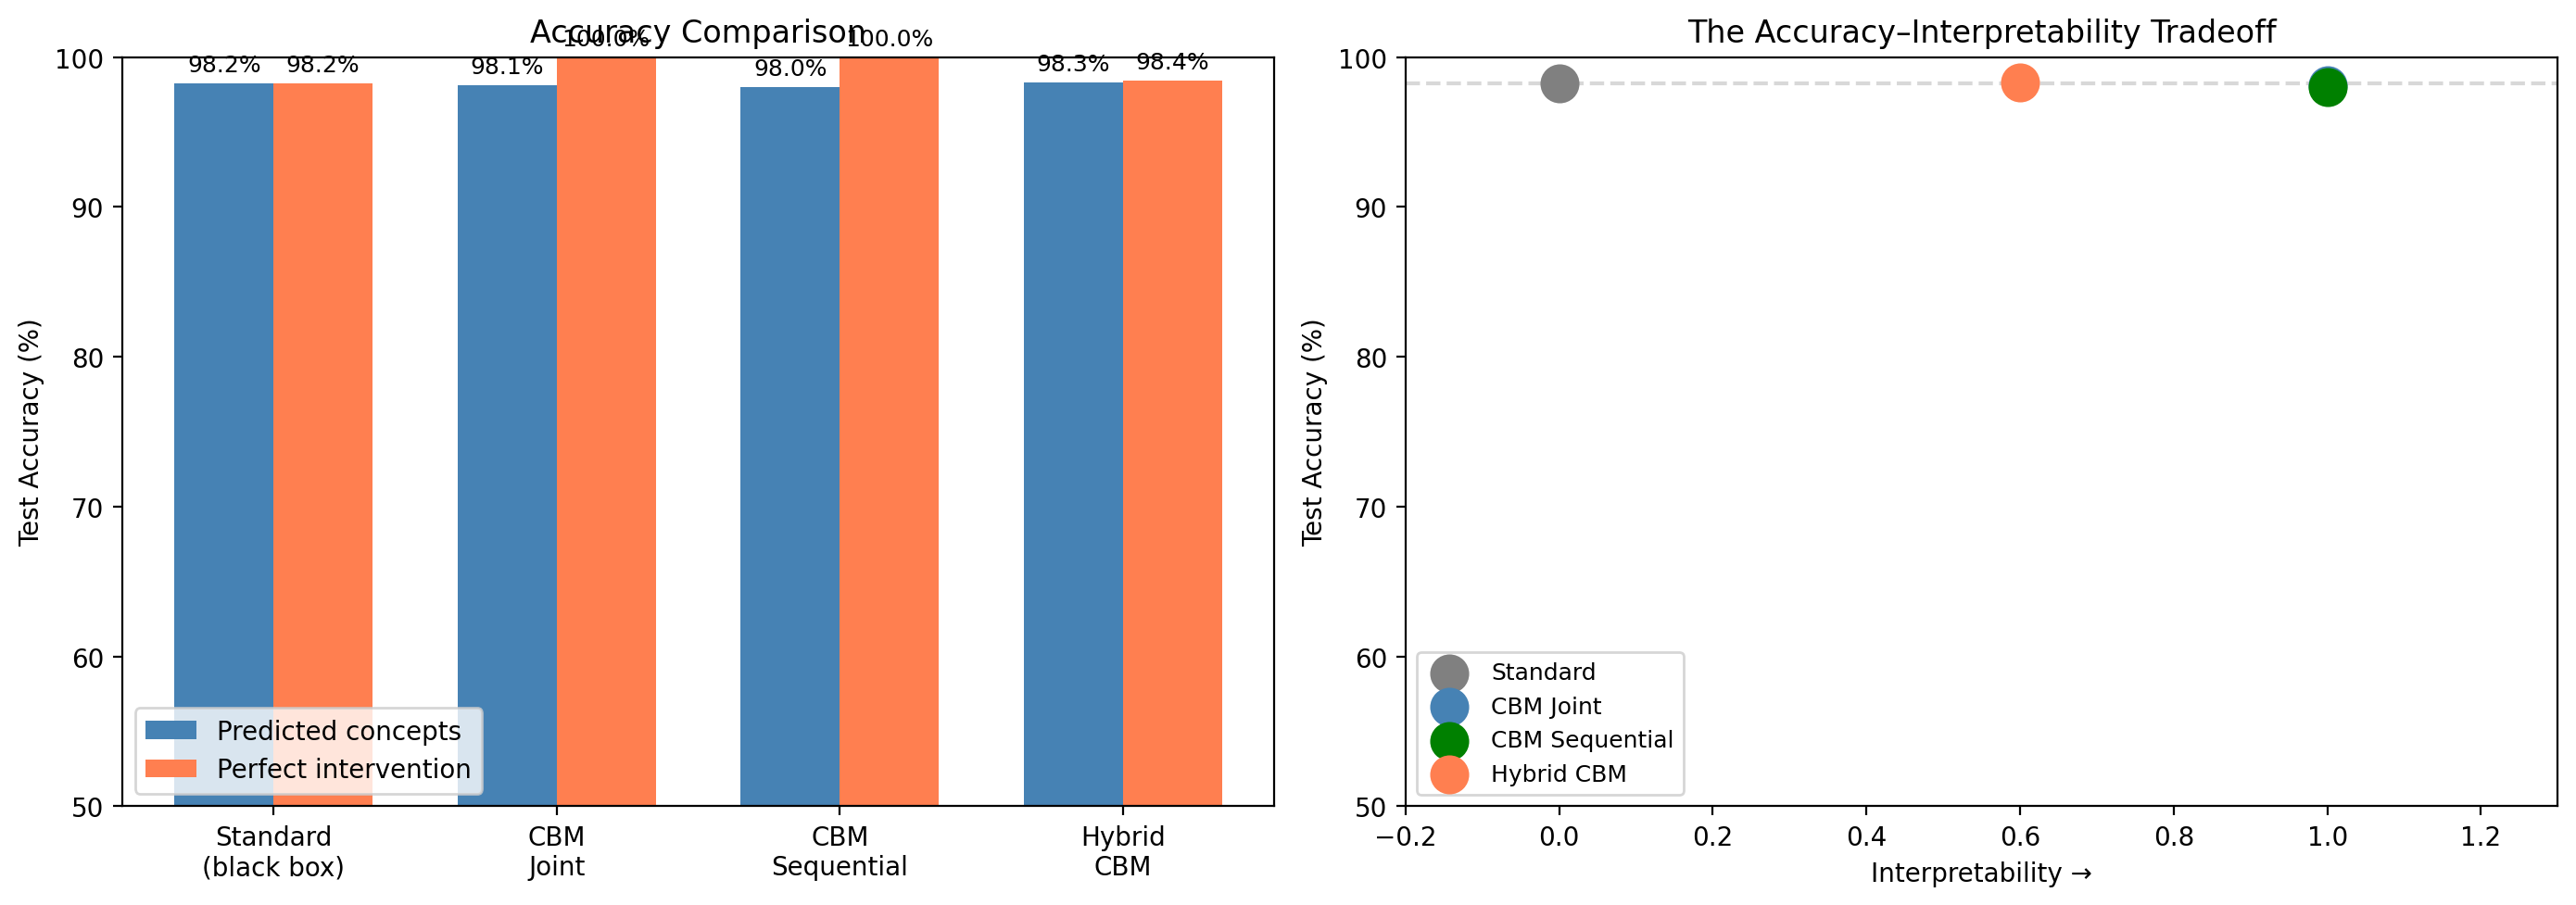

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of accuracies
models_names = ['Standard\n(black box)', 'CBM\nJoint', 'CBM\nSequential', 'Hybrid\nCBM']
accs = [std_acc, joint_results['label_acc'], seq_results['label_acc'], hybrid_results['label_acc']]
intervened = [std_acc, joint_results['intervened_acc'], seq_results['intervened_acc'], hybrid_results['intervened_acc']]
interpretability = [0, 1.0, 1.0, 0.6]  # relative interpretability score

x = np.arange(len(models_names))
w = 0.35
bars1 = axes[0].bar(x - w/2, [a*100 for a in accs], w, label='Predicted concepts', color='steelblue')
bars2 = axes[0].bar(x + w/2, [a*100 for a in intervened], w, label='Perfect intervention', color='coral')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names)
axes[0].legend()
axes[0].set_ylim(50, 100)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# Right: accuracy vs interpretability scatter
axes[1].scatter([0], [std_acc*100], s=200, c='gray', zorder=5, label='Standard')
axes[1].scatter([1.0], [joint_results['label_acc']*100], s=200, c='steelblue', zorder=5, label='CBM Joint')
axes[1].scatter([1.0], [seq_results['label_acc']*100], s=200, c='green', zorder=5, label='CBM Sequential')
axes[1].scatter([0.6], [hybrid_results['label_acc']*100], s=200, c='coral', zorder=5, label='Hybrid CBM')
axes[1].set_xlabel('Interpretability →')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('The Accuracy–Interpretability Tradeoff')
axes[1].legend(fontsize=9)
axes[1].set_xlim(-0.2, 1.3)
axes[1].set_ylim(50, 100)
axes[1].axhline(y=std_acc*100, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Inspecting Concepts — The Key Advantage

For any prediction, we can look at the predicted concept activations and understand
*what the model thinks it sees*. This is impossible with a standard model.

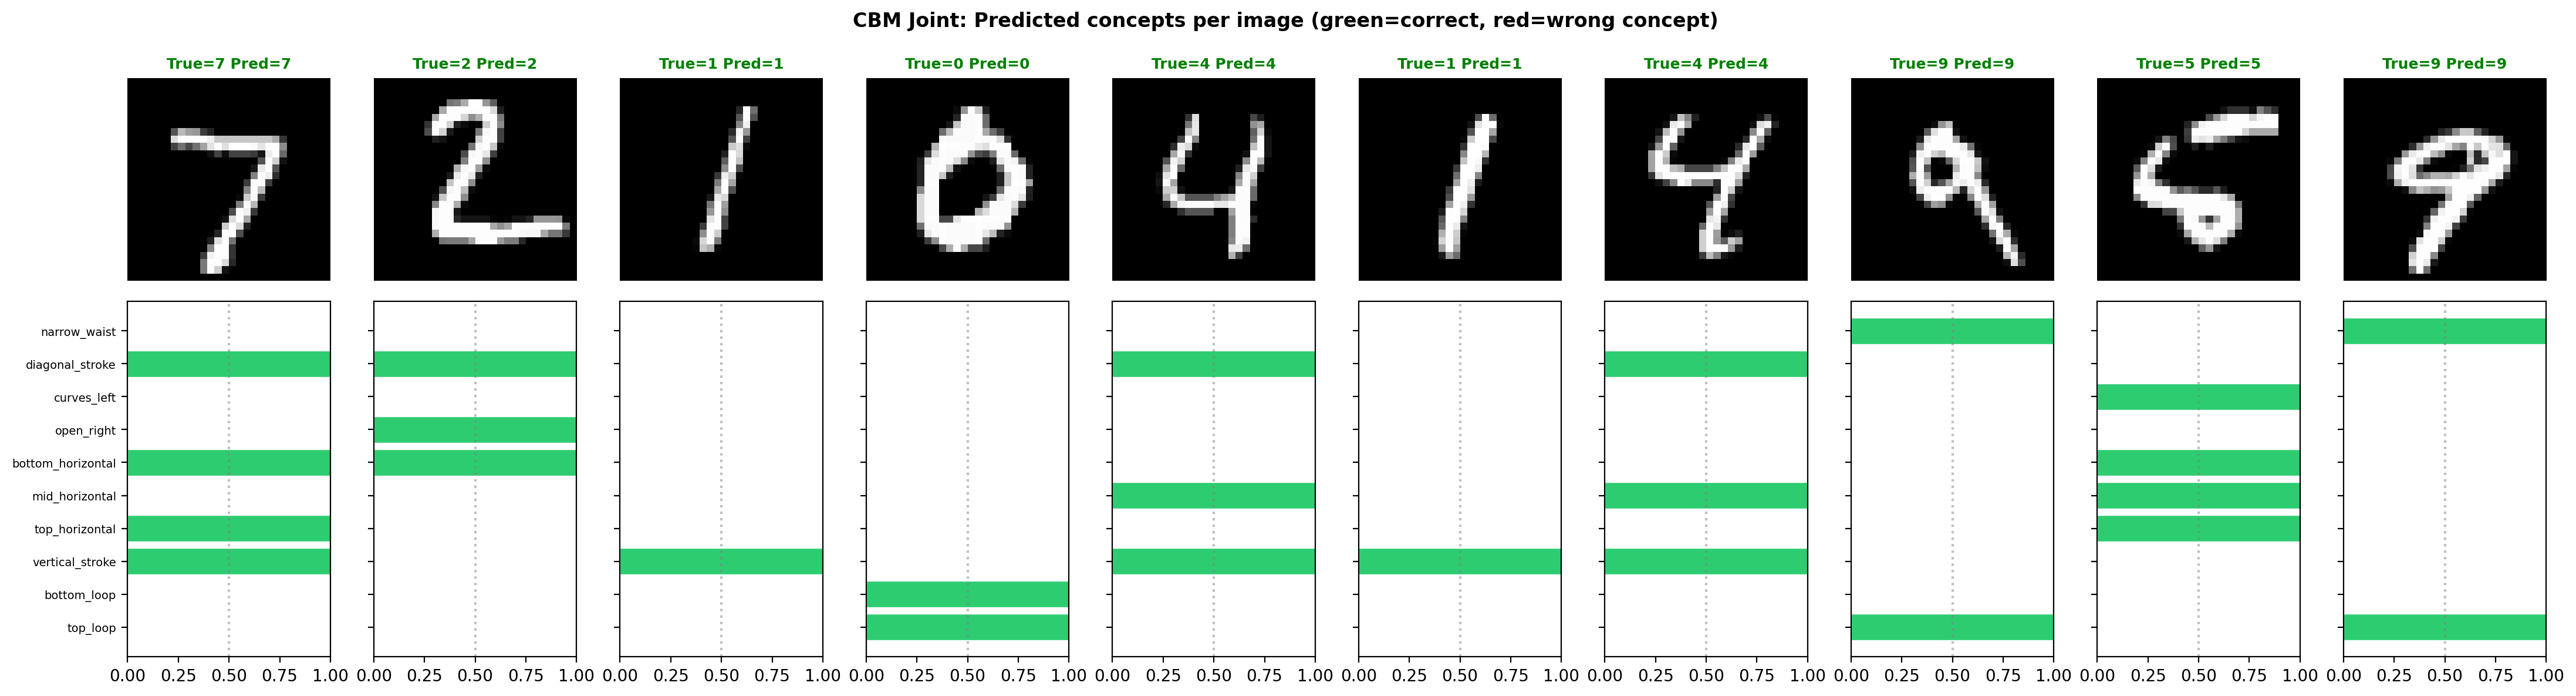

In [21]:
@torch.no_grad()
def show_predictions(model, images, labels, title="CBM", n=10):
    model.eval()
    images_d = images[:n].to(device)
    _, concept_probs, label_logits = model(images_d)
    pred_labels = label_logits.argmax(dim=1)
    
    fig, axes = plt.subplots(2, n, figsize=(2.2*n, 6),
                            gridspec_kw={'height_ratios': [1, 1.5]})
    
    for i in range(n):
        # Image
        axes[0, i].imshow(images[i, 0].cpu(), cmap='gray')
        correct = pred_labels[i].item() == labels[i].item()
        axes[0, i].set_title(f"True={labels[i].item()} Pred={pred_labels[i].item()}",
                            fontsize=9, color='green' if correct else 'red',
                            fontweight='bold')
        axes[0, i].axis('off')
        
        # Concept activations
        probs = concept_probs[i].cpu().numpy()
        true_c = concept_matrix[labels[i]].numpy()
        colors = ['#2ecc71' if (p > 0.5) == t else '#e74c3c' for p, t in zip(probs, true_c)]
        axes[1, i].barh(range(NUM_CONCEPTS), probs, color=colors, edgecolor='white', linewidth=0.5)
        axes[1, i].set_xlim(0, 1)
        axes[1, i].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
        axes[1, i].set_yticks(range(NUM_CONCEPTS))
        if i == 0:
            axes[1, i].set_yticklabels(CONCEPT_NAMES, fontsize=7)
        else:
            axes[1, i].set_yticklabels([])
    
    plt.suptitle(f'{title}: Predicted concepts per image (green=correct, red=wrong concept)',
                fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(cbm_joint, test_imgs, test_labels, "CBM Joint", n=10)

## 8. Concept Intervention Demo

This is the **killer feature** of CBMs. When the model gets something wrong, a human
can inspect the predicted concepts, spot the error, and correct it. The corrected
concepts flow through the label head to (hopefully) fix the final prediction.

This is fundamentally impossible with a standard black-box model.

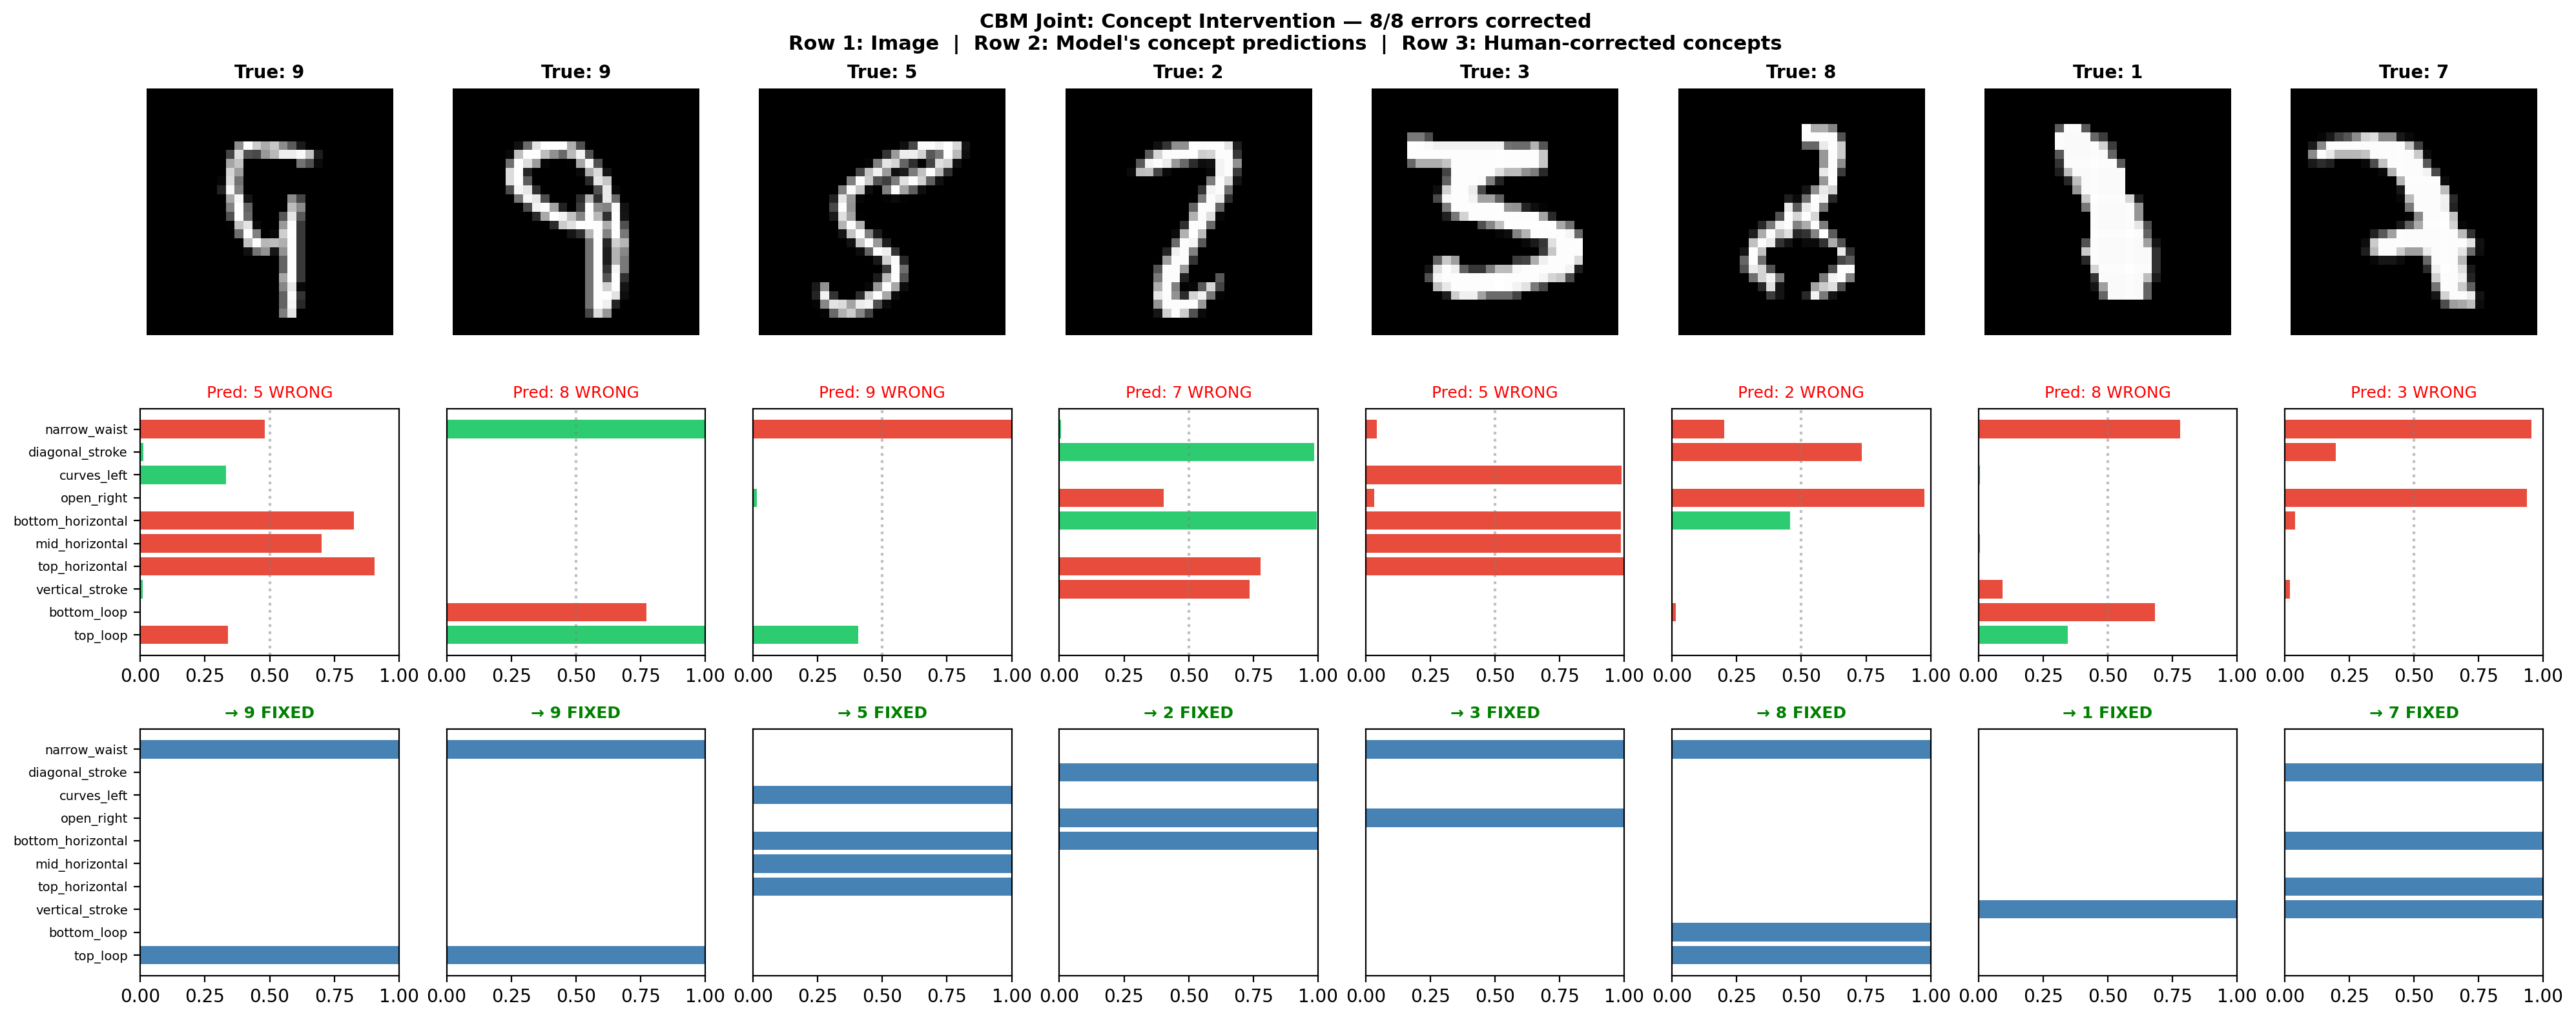

8/8 misclassifications fixed by concept intervention.


In [22]:
@torch.no_grad()
def intervention_demo(model, images, labels, concepts, model_name="CBM"):
    model.eval()
    images_d = images.to(device)
    
    _, pred_probs, pred_logits = model(images_d)
    pred_labels = pred_logits.argmax(dim=1).cpu()
    
    # Find misclassified examples
    wrong_mask = pred_labels != labels
    wrong_indices = wrong_mask.nonzero().squeeze(-1)
    
    if len(wrong_indices) == 0:
        print("No misclassified examples!")
        return
    
    # Take up to 8 wrong examples
    wrong_indices = wrong_indices[:8]
    n = len(wrong_indices)
    
    # Intervene with ground-truth concepts
    true_c = concepts[wrong_indices].to(device)
    _, _, fixed_logits = model(images_d[wrong_indices], concept_override=true_c)
    fixed_labels = fixed_logits.argmax(dim=1).cpu()
    
    fig, axes = plt.subplots(3, n, figsize=(2.5*n, 8))
    if n == 1:
        axes = axes.reshape(3, 1)
    
    fixed_count = 0
    for j, idx in enumerate(wrong_indices):
        i = idx.item()
        
        axes[0, j].imshow(images[i, 0], cmap='gray')
        axes[0, j].set_title(f"True: {labels[i].item()}", fontsize=10, fontweight='bold')
        axes[0, j].axis('off')
        
        # Predicted concepts (wrong)
        probs = pred_probs[i].cpu().numpy()
        true_cv = concepts[i].numpy()
        colors = ['#2ecc71' if (p > 0.5) == t else '#e74c3c' for p, t in zip(probs, true_cv)]
        axes[1, j].barh(range(NUM_CONCEPTS), probs, color=colors)
        axes[1, j].set_xlim(0, 1)
        axes[1, j].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
        axes[1, j].set_title(f"Pred: {pred_labels[i].item()} WRONG", fontsize=9, color='red')
        if j == 0:
            axes[1, j].set_yticks(range(NUM_CONCEPTS))
            axes[1, j].set_yticklabels(CONCEPT_NAMES, fontsize=7)
        else:
            axes[1, j].set_yticks([])
        
        # After intervention
        was_fixed = fixed_labels[j].item() == labels[i].item()
        fixed_count += int(was_fixed)
        axes[2, j].barh(range(NUM_CONCEPTS), true_cv, color='steelblue')
        axes[2, j].set_xlim(0, 1)
        symbol = 'FIXED' if was_fixed else 'STILL WRONG'
        axes[2, j].set_title(f"→ {fixed_labels[j].item()} {symbol}",
                            fontsize=9, color='green' if was_fixed else 'orange', fontweight='bold')
        if j == 0:
            axes[2, j].set_yticks(range(NUM_CONCEPTS))
            axes[2, j].set_yticklabels(CONCEPT_NAMES, fontsize=7)
        else:
            axes[2, j].set_yticks([])
    
    plt.suptitle(
        f'{model_name}: Concept Intervention — {fixed_count}/{n} errors corrected\n'
        f'Row 1: Image  |  Row 2: Model\'s concept predictions  |  Row 3: Human-corrected concepts',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    print(f"{fixed_count}/{n} misclassifications fixed by concept intervention.")


intervention_demo(cbm_joint, test_imgs, test_labels, test_concepts, "CBM Joint")

## 9. Inspect the Label Head — Fully Interpretable Weights

Because the label head is a single linear layer from concepts → digits, its weights
directly tell us: *"To predict digit X, look for concepts A, B, C and look for absence of D, E."*

This is a white-box decision rule, not a black-box approximation.

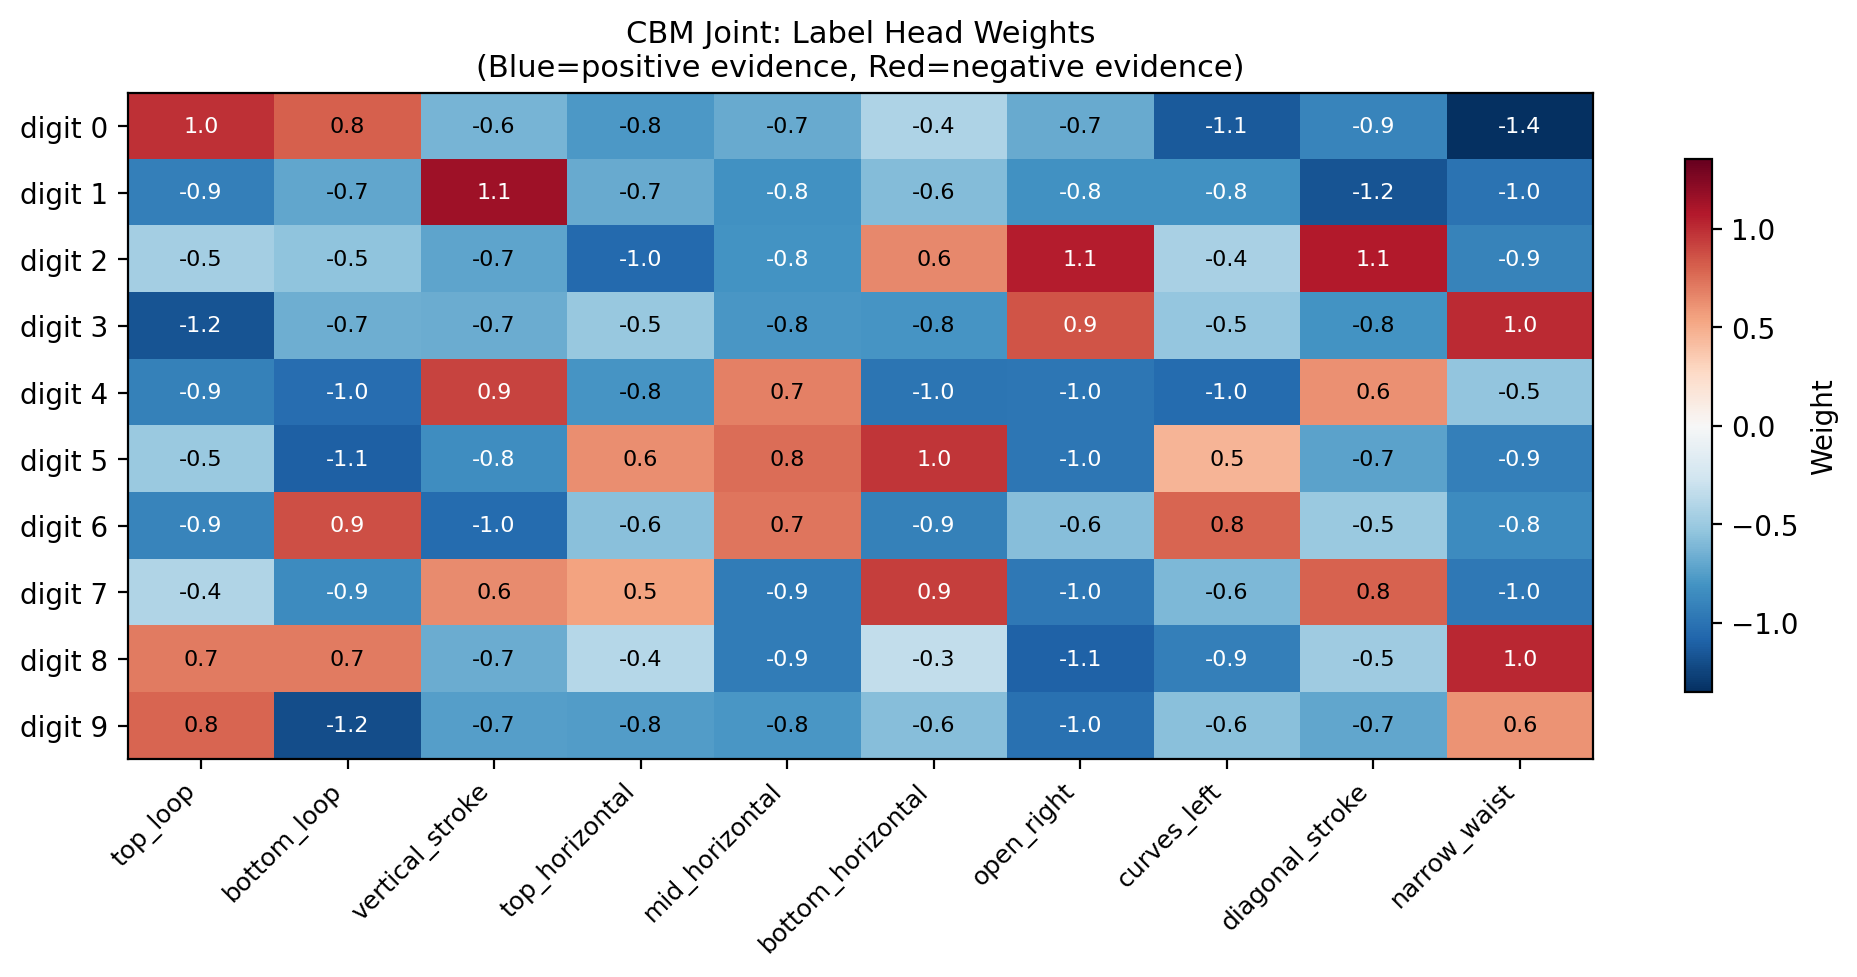

In [23]:
def plot_label_weights(model, title):
    weights = model.label_head[0].weight.detach().cpu().numpy() if isinstance(model.label_head, nn.Sequential) \
              else model.label_head.weight.detach().cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    vmax = np.abs(weights).max()
    im = ax.imshow(weights, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(NUM_CONCEPTS))
    ax.set_xticklabels(CONCEPT_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels([f'digit {i}' for i in range(10)])
    ax.set_title(f'{title}: Label Head Weights\n(Blue=positive evidence, Red=negative evidence)', fontsize=11)
    plt.colorbar(im, label='Weight', shrink=0.8)
    
    for i in range(NUM_CLASSES):
        for j in range(NUM_CONCEPTS):
            ax.text(j, i, f'{weights[i,j]:.1f}', ha='center', va='center', fontsize=8,
                   color='white' if abs(weights[i,j]) > vmax*0.6 else 'black')
    plt.tight_layout()
    plt.show()

plot_label_weights(cbm_joint, "CBM Joint")

### Reading the weight matrix

Each row shows how the model uses concepts to recognize that digit. For example:
- **Digit 0** should have large positive weights for `top_loop` and `bottom_loop`
- **Digit 1** should have a large positive weight for `vertical_stroke` and negative weights for loops
- **Digit 8** should look like digit 0 (both loops) but also use `narrow_waist` to distinguish itself

Compare this to the ground-truth concept matrix above — the weights should roughly mirror it.

## 10. Per-concept Accuracy Breakdown

Which concepts are easy to predict from pixels? Which are hard?

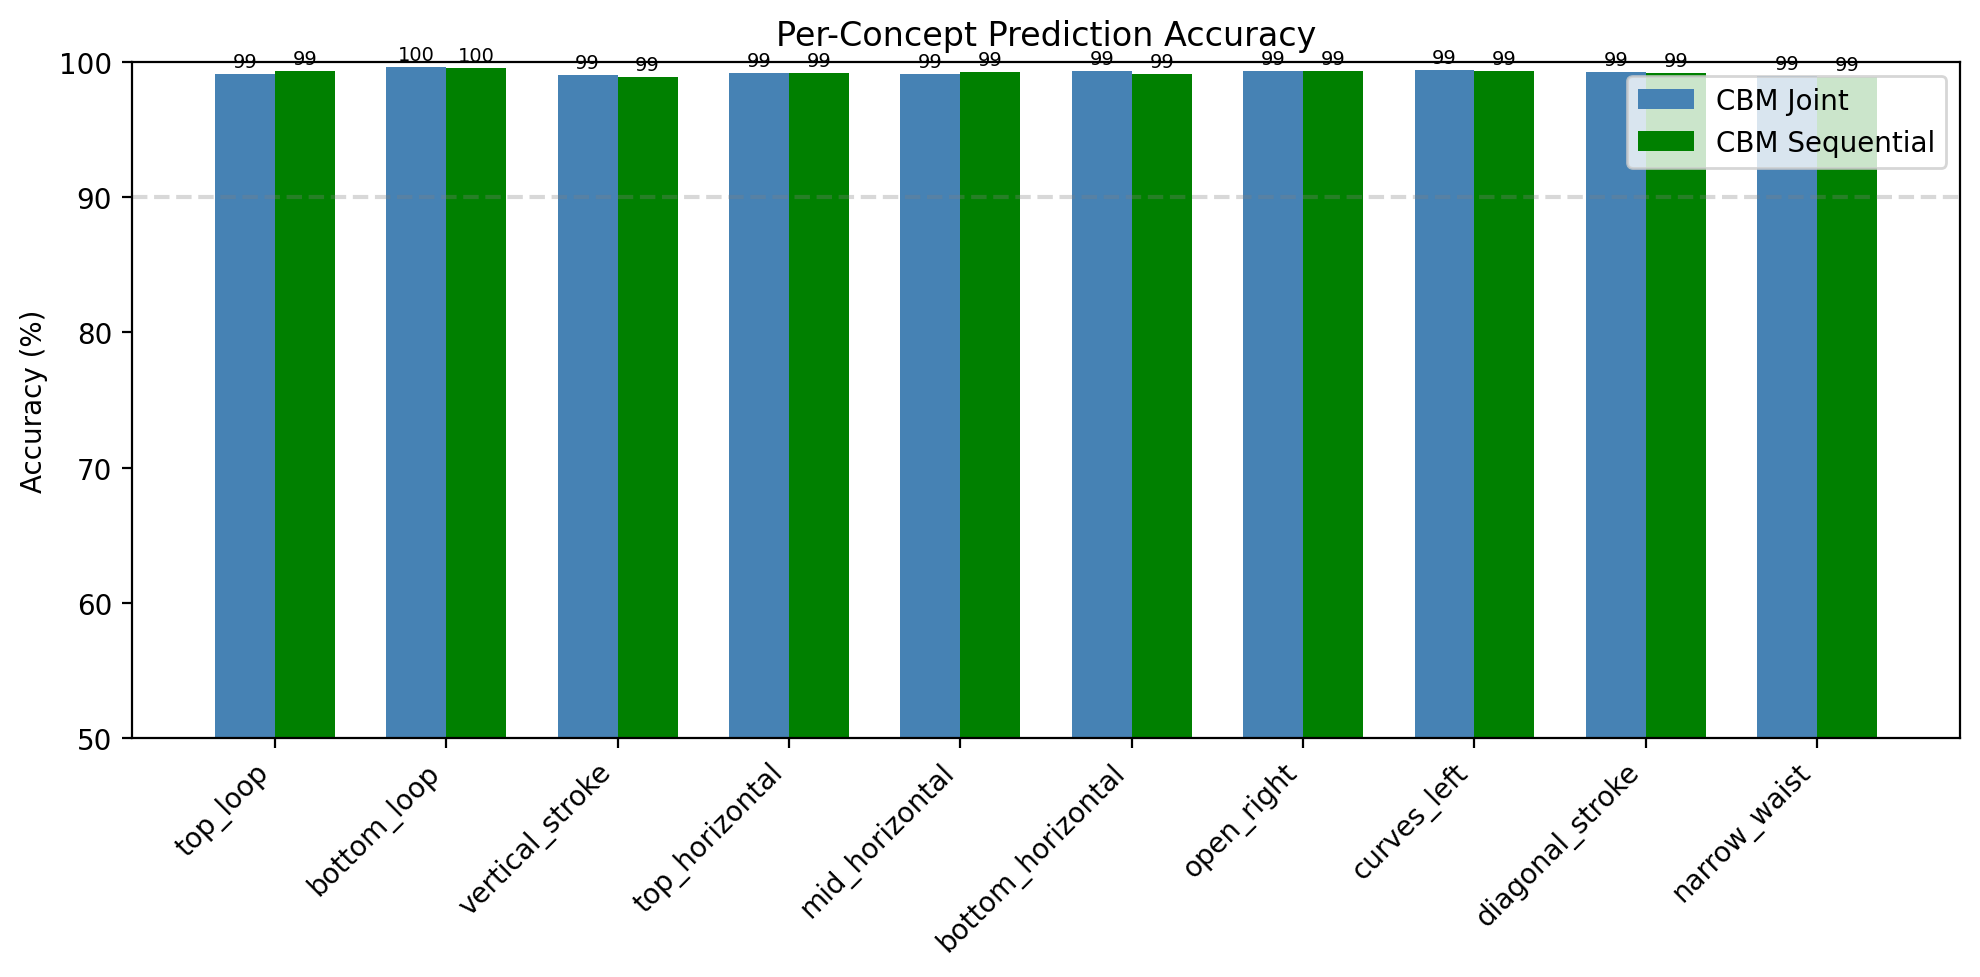

In [24]:
@torch.no_grad()
def per_concept_accuracy(model, dl):
    model.eval()
    correct = torch.zeros(NUM_CONCEPTS)
    total = 0
    for imgs, concepts, _ in dl:
        imgs, concepts = imgs.to(device), concepts.to(device)
        _, c_probs, _ = model(imgs)
        preds = (c_probs > 0.5).float()
        correct += (preds == concepts).sum(dim=0).cpu()
        total += imgs.size(0)
    return (correct / total).numpy()

concept_accs_joint = per_concept_accuracy(cbm_joint, test_dl)
concept_accs_seq = per_concept_accuracy(cbm_seq, test_dl)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CONCEPTS)
w = 0.35
ax.bar(x - w/2, concept_accs_joint * 100, w, label='CBM Joint', color='steelblue')
ax.bar(x + w/2, concept_accs_seq * 100, w, label='CBM Sequential', color='green')
ax.set_xticks(x)
ax.set_xticklabels(CONCEPT_NAMES, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Concept Prediction Accuracy')
ax.legend()
ax.set_ylim(50, 100)
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.3, label='90% threshold')
for i, (j_acc, s_acc) in enumerate(zip(concept_accs_joint, concept_accs_seq)):
    ax.text(i - w/2, j_acc*100 + 0.5, f'{j_acc*100:.0f}', ha='center', fontsize=7)
    ax.text(i + w/2, s_acc*100 + 0.5, f'{s_acc*100:.0f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

## 11. Training Dynamics — Loss Curves

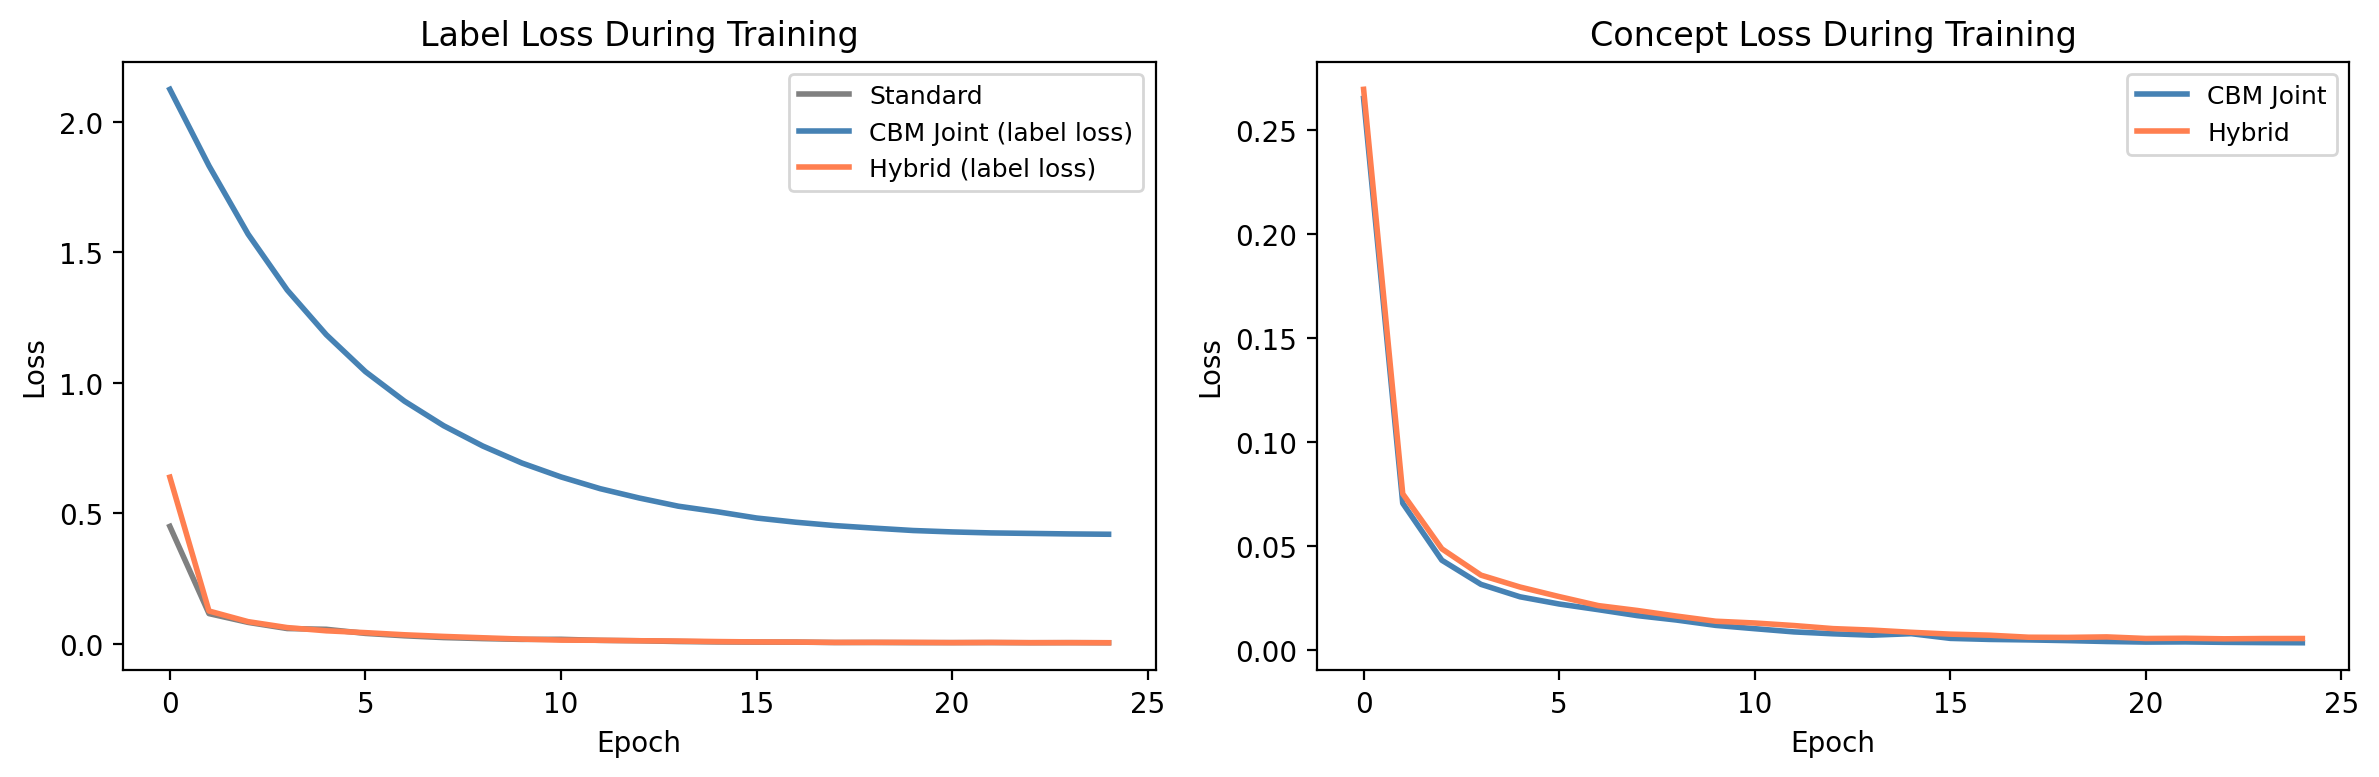

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(std_hist, label='Standard', color='gray', linewidth=2)
axes[0].plot(cbm_joint_hist['label_loss'], label='CBM Joint (label loss)', color='steelblue', linewidth=2)
axes[0].plot(hybrid_hist['label_loss'], label='Hybrid (label loss)', color='coral', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Label Loss During Training')
axes[0].legend(fontsize=9)

axes[1].plot(cbm_joint_hist['concept_loss'], label='CBM Joint', color='steelblue', linewidth=2)
axes[1].plot(hybrid_hist['concept_loss'], label='Hybrid', color='coral', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Concept Loss During Training')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()